## Dependencies

In [1]:
import copy
import joblib
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import optuna
import os
import pandas as pd
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from thermo.unifac import UFIP, UFSG, UNIFAC
from torchmetrics.regression import R2Score

## PINN modeling

Defining model constants and fix random seed

In [2]:
# Fix random seed
torch.manual_seed(42)

# Constants
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10000

### Designing the Neural Network Components

Define the architecture of the neural network for FP prediction

In [3]:
class NeuralNetArchitecture(nn.Module):
    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.layer_1 = nn.Linear(in_dim, 16)
        self.layer_2 = nn.Linear(16, 8)
        self.layer_3 = nn.Linear(8, out_dim)

    def forward(self, x):
        x = F.relu(self.layer_1(x))
        x = F.relu(self.layer_2(x))
        x = self.layer_3(x)

        return x

Define the class containing vapor pressure models

In [4]:
class VaporPressureCalculation:
    @staticmethod
    def ceriani_pvap(
        nCH3: float,
        nCH2: float,
        nCDC: float,
        nCOO: float,
        Ncs: float,
        Mi: float,
        T: float,
    ) -> float:
        n = [nCH3, nCH2, nCDC, nCOO]
        nc = sum(n)
        f0 = 0.0
        f1 = 0.0
        s0 = -0.658
        s1 = 0.12
        alfa = -3.8639
        beta = 2081.7
        ABC1K = [
            [1.0583, -3.1789, -2.6923, 3.6559],
            [1780.8, 1756.7, 1664.6, 4880.9],
            [0.011484, -0.64358, -0.64371, -3.896],
        ]
        ABC2K = [
            [0.2891, 0.0000082404, 0.00000824, -0.012577],
            [-87.312, -0.11714, -0.11857, -1.2848],
            [-0.000038873, 0.0000474, 0.000048389, 0.0024548],
        ]

        # Calculating Ac, Bc and Cc
        ac = 0.0
        bc = 0.0
        cc = 0.0

        for i in range(0, 4):
            ac = ac + (n[i] * (ABC1K[0][i] + (Mi * ABC2K[0][i])))

            bc = bc + (n[i] * (ABC1K[1][i] + (Mi * ABC2K[1][i])))

            cc = cc + (n[i] * (ABC1K[2][i] + (Mi * ABC2K[2][i])))

        ac = ac + (s0 + Ncs * s1) + alfa * (f0 + nc * f1)

        bc = bc + beta * (f0 + nc * f1)

        if not np.isnan(T) and not np.isinf(T) and T > 0:
            pvap = math.e ** (ac + (bc / T) + cc * np.log(T))
        else:
            pvap = 0

        return pvap

    @staticmethod
    def antoine_pvap(A: float, B: float, C: float, T: float) -> float:
        p_vap = 10.0 ** (A - (B / (T + C)))

        return p_vap * 1000.0

Implement a custom loss function that enforces Liaw's equation into the standard MSE loss

In [5]:
def custom_liaw_loss(
    y_pred: torch.Tensor,
    y_true: torch.Tensor,
    mol_frac: torch.Tensor,
    gamma: torch.Tensor,
    pvap: torch.Tensor,
    pvap_fp: torch.Tensor,
    epoch: int,
    model: nn.Module,
    lambda_liaw: float = 1e2,
    lambda_l1: float = 0.0,
) -> torch.tensor:
    # MSE loss
    mse_loss = F.mse_loss(y_pred, y_true, reduction="mean")

    # Liaw loss
    liaw_summation = torch.sum(mol_frac * gamma * pvap / pvap_fp, dim=1)
    liaw_residual = 1 - liaw_summation
    liaw_loss = torch.mean(liaw_residual**2) * lambda_liaw

    # L1 regularization term
    l1_loss = (sum(p.abs().sum() for p in model.parameters())) * lambda_l1

    # Total loss
    if epoch >= 2000:
        total_loss = mse_loss + liaw_loss + l1_loss
    else:
        total_loss = mse_loss + l1_loss

    return total_loss, liaw_residual

### Reading the data

Defining the data path conveniently:

In [6]:
DATA_PATH = Path("../data")

Reading the data into a `pandas.DataFrame`:

In [7]:
data = pd.read_csv(DATA_PATH / "processed" / "fp_training_dataset.csv")

data

,r_1,q_1,x_1,r_2,q_2,x_2,MM,lnPvap,Method,substance_1,substance_2,FP
0,10.6006,8.836,1.000,0.0000,0.000,0.000,228.37,-1.450000,0,ethyl laurate,NaN,402.30
1,2.5755,2.588,0.005,5.8486,4.936,0.995,113.86,7.575678,1,ethanol,octane,286.15
2,2.5755,2.588,0.010,5.8486,4.936,0.990,113.49,7.593094,1,ethanol,octane,283.45
3,2.5755,2.588,0.020,5.8486,4.936,0.980,112.75,7.627042,1,ethanol,octane,281.95
4,2.5755,2.588,0.030,5.8486,4.936,0.970,112.00,7.659875,1,ethanol,octane,280.75
...,...,...,...,...,...,...,...,...,...,...,...,...
361,5.8486,4.936,1.000,0.0000,0.000,0.000,114.23,7.557953,1,octane,NaN,287.65
362,2.5755,2.588,1.000,0.0000,0.000,0.000,40.07,9.078902,1,ethanol,NaN,286.15
363,4.5310,3.976,1.000,0.0000,0.000,0.000,102.13,4.172583,1,methyl butyrate,NaN,284.55
364,4.5310,3.976,1.000,0.0000,0.000,0.000,102.13,3.902982,1,propyl acetate,NaN,284.55


Reading the substance parameters json

In [8]:
with open(
    DATA_PATH / "models_parameters" / "substance_params.json", "r", encoding="utf-8"
) as file:
    sub_params = json.load(file)

Retrieving the UNIFAC parameters for each substance

In [9]:
sys.path.append(os.path.abspath(os.path.join("..", "data")))

from models_parameters.unifac_groups import GROUPS

### Preprocessing

Creating method to calculate vapor pressure for each component in the dataset

In [10]:
def compute_vapor_pressure(
    component_array: np.array, T_K_tensor: torch.tensor
) -> tuple[torch.tensor, torch.tensor]:
    n_rows, n_cols = component_array.shape
    pvap_at_T = torch.empty((n_rows, n_cols), dtype=torch.float32)
    pvap_at_FP = torch.empty((n_rows, n_cols), dtype=torch.float32)

    T_K_array = T_K_tensor.detach().cpu().squeeze(-1)

    for i, row in enumerate(component_array):
        T_K = T_K_array[i]
        for j, component in enumerate(row):
            if isinstance(component, str):
                params = sub_params.get(component)
                if not params:
                    pvap_at_T[i, j] = 0.0
                    pvap_at_FP[i, j] = 0.0
                    continue

                model = params.get("model")

                if model == "Antoine":
                    A, B, C, T_FP = params["A"], params["B"], params["C"], params["FP"]
                    pvap_T = VaporPressureCalculation.antoine_pvap(A, B, C, T_K)
                    pvap_FP = VaporPressureCalculation.antoine_pvap(A, B, C, T_FP)

                else:
                    nCH3, nCH2, nCDC, nCOO, Ncs, Mi, T_FP = (
                        params["nCH3"],
                        params["nCH2"],
                        params["nCDC"],
                        params["nCOO"],
                        params["Ncs"],
                        params["Mi"],
                        params["FP"],
                    )
                    pvap_T = VaporPressureCalculation.ceriani_pvap(
                        nCH3, nCH2, nCDC, nCOO, Ncs, Mi, T_K
                    )
                    pvap_FP = VaporPressureCalculation.ceriani_pvap(
                        nCH3, nCH2, nCDC, nCOO, Ncs, Mi, T_FP
                    )

            pvap_at_T[i, j] = (
                pvap_T if not (np.isnan(pvap_T) or np.isinf(pvap_T)) else 0
            )
            pvap_at_FP[i, j] = (
                pvap_FP if not (np.isnan(pvap_FP) or np.isinf(pvap_FP)) else 0
            )

    return pvap_at_T.to(DEVICE), pvap_at_FP.to(DEVICE)

Creating method to calculate activity coefficient for each row in the dataset

In [11]:
def compute_activity_coefficients(
    component_array: np.array, mol_frac_array: np.array, T_K_tensor: torch.tensor
) -> torch.tensor:
    n_rows, n_cols = component_array.shape
    gamma_array = np.ones((n_rows, n_cols), dtype=np.float32)
    T_K_array = T_K_tensor.detach().cpu().squeeze(-1).numpy()

    for i in range(n_rows):
        components = component_array[i]
        mol_frac = mol_frac_array[i]
        T_K = T_K_array[i]

        # Check for pure system
        is_pure = (mol_frac[0] == 1.0 and mol_frac[1] == 0.0) or (
            mol_frac[0] == 0.0 and mol_frac[1] == 1.0
        )

        if is_pure:
            gamma_array[i] = [1.0, 1.0]
            continue

        try:
            chemgroups = [GROUPS[comp] for comp in components]
            GE = UNIFAC.from_subgroups(
                chemgroups=chemgroups,
                T=T_K,
                xs=mol_frac,
                version=0,
                interaction_data=UFIP,
                subgroups=UFSG,
            )

            gammas = GE.gammas()
            gamma_array[i] = gammas[:2]

        except Exception:
            gamma_array[i] = [1.0, 1.0]

    return torch.tensor(gamma_array, dtype=torch.float32).to(DEVICE)

### Training

Retrieving the features and label for PINN

In [12]:
features = data[
    [
        "MM",
        "lnPvap",
        "Method",
        "x_1",
        "x_2",
        "substance_1",
        "substance_2",
    ]
].values
label = data[["FP"]].values

Defining model data path

In [13]:
MODEL_PATH = Path("../src/models")

Defining the Optuna objective function to find the best hyperparameters

In [ ]:
def objective(trial):
    # Hyperparameters
    learning_rate = trial.suggest_loguniform("lr", 1e-5, 1e-2)
    lambda_liaw = trial.suggest_loguniform("lambda_liaw", 1e-2, 1e3)
    lambda_l1 = trial.suggest_loguniform("lambda_l1", 1e-6, 1e-1)

    fold_losses = []

    # Define the cross-validation folds
    folds = 5
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(features)):
        # Split data into train and validation
        X_train_fold, X_val_fold = features[train_idx], features[val_idx]
        y_train_fold, y_val_fold = label[train_idx], label[val_idx]

        # Scaler for FP model
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold[:, :-4])
        X_val_scaled = scaler.transform(X_val_fold[:, :-4])

        # Convert to tensors
        X_train_tensor = torch.tensor(
            X_train_scaled, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)
        y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).to(DEVICE)
        X_val_tensor = torch.tensor(
            X_val_scaled, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)
        y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).to(DEVICE)

        # Get molar fraction tensor
        mol_frac_train = X_train_fold[:, 3:5].astype(np.float32)
        mol_frac_val = X_val_fold[:, 3:5].astype(np.float32)
        mol_frac_train_tensor = torch.tensor(
            mol_frac_train, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)
        mol_frac_val_tensor = torch.tensor(
            mol_frac_val, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)

        # Model and optimizer for FP
        model = NeuralNetArchitecture(in_dim=X_train_tensor.shape[1], out_dim=1).to(
            DEVICE
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        best_val_loss = float("inf")
        for epoch in range(EPOCHS):
            model.train()
            outputs = model(X_train_tensor)

            gamma = compute_activity_coefficients(
                X_train_fold[:, -2:], mol_frac_train, outputs
            )
            pvap, pvap_fp = compute_vapor_pressure(X_train_fold[:, -2:], outputs)

            loss, _ = custom_liaw_loss(
                outputs,
                y_train_tensor,
                mol_frac_train_tensor,
                gamma,
                pvap,
                pvap_fp,
                epoch,
                model,
                lambda_liaw=lambda_liaw,
                lambda_l1=lambda_l1,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            model.eval()
            val_outputs = model(X_val_tensor)

            val_gamma = compute_activity_coefficients(
                X_val_fold[:, -2:], mol_frac_val, val_outputs
            )
            val_pvap, val_pvap_fp = compute_vapor_pressure(
                X_val_fold[:, -2:], val_outputs
            )

            val_loss, _ = custom_liaw_loss(
                val_outputs,
                y_val_tensor,
                mol_frac_val_tensor,
                val_gamma,
                val_pvap,
                val_pvap_fp,
                epoch,
                model,
                lambda_liaw=lambda_liaw,
                lambda_l1=lambda_l1,
            )

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()

        fold_losses.append(best_val_loss)

    return np.mean(fold_losses)


After hyperparameter tunning, the best set of hyperparameters were:
- Learning rate -> 0.001617535621120388
- Lambda Liaw -> 0.4968055674914427
- Lambda L1 -> 0.0005837960921148273

Get the best hyperparameters

In [ ]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best hyperparameters:")
print(study.best_params)

Define best hyperparameters

In [14]:
best_lr = 0.001617535621120388
best_lambda_liaw = 0.4968055674914427
best_lambda_l1 = 0.0005837960921148273

### Evaluation

Define plotting functions

In [15]:
def plot_residuals_histogram(residuals: np.ndarray):
    mean_residual = np.mean(residuals)
    ax = plt.gca()
    ax.hist(residuals, bins=20, edgecolor="black", alpha=0.7)
    ax.axvline(
        mean_residual, color="red", linestyle="--", label=f"Mean = {mean_residual:.2f}"
    )
    ax.set_xlabel("Liaw Residual")
    ax.set_ylabel("Frequency")
    ax.set_title("Histogram of Residuals")
    ax.grid(True)
    ax.legend()


def plot_pred_vs_exp(y_true: np.ndarray, y_pred: np.ndarray, r2: float):
    ax = plt.gca()
    ax.scatter(y_true, y_pred, label=f"R² = {r2:.4f}")
    ax.set_xlabel("Experimental values (K)")
    ax.set_ylabel("Predicted values (K)")
    ax.axis("equal")
    ax.axis("square")
    ax.set_xlim([250, max(ax.get_xlim()[1], ax.get_ylim()[1])])
    ax.set_ylim([250, max(ax.get_xlim()[1], ax.get_ylim()[1])])
    ax.plot(
        [250, max(ax.get_xlim()[1], ax.get_ylim()[1])],
        [250, max(ax.get_xlim()[1], ax.get_ylim()[1])],
        linestyle="--",
        color="gray",
        label="Ideal line",
    )
    ax.legend(loc="upper left")

Plotting Predicted vs Experimental Values for each Fold during the cross-validation with the best model

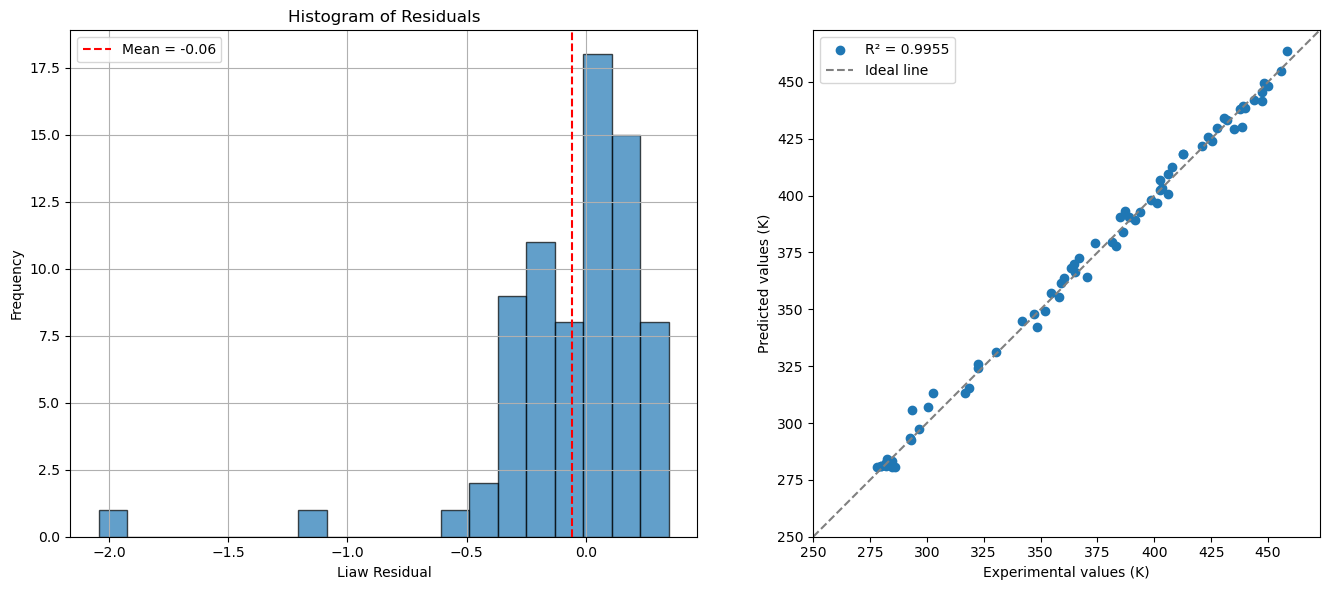

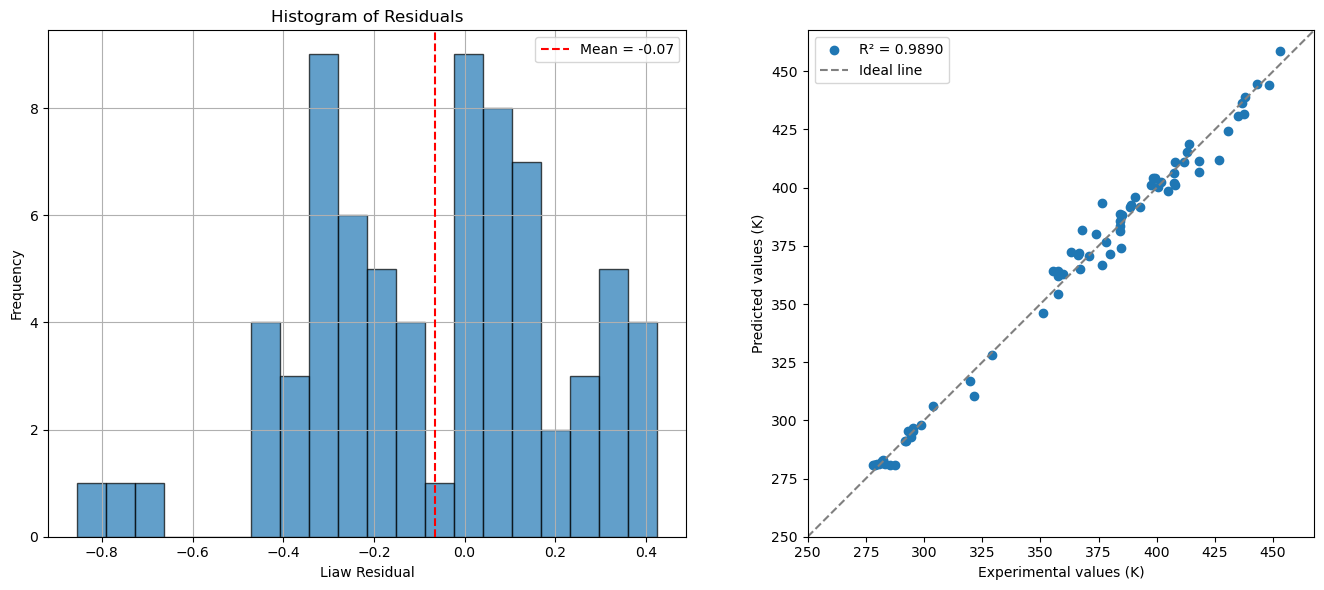

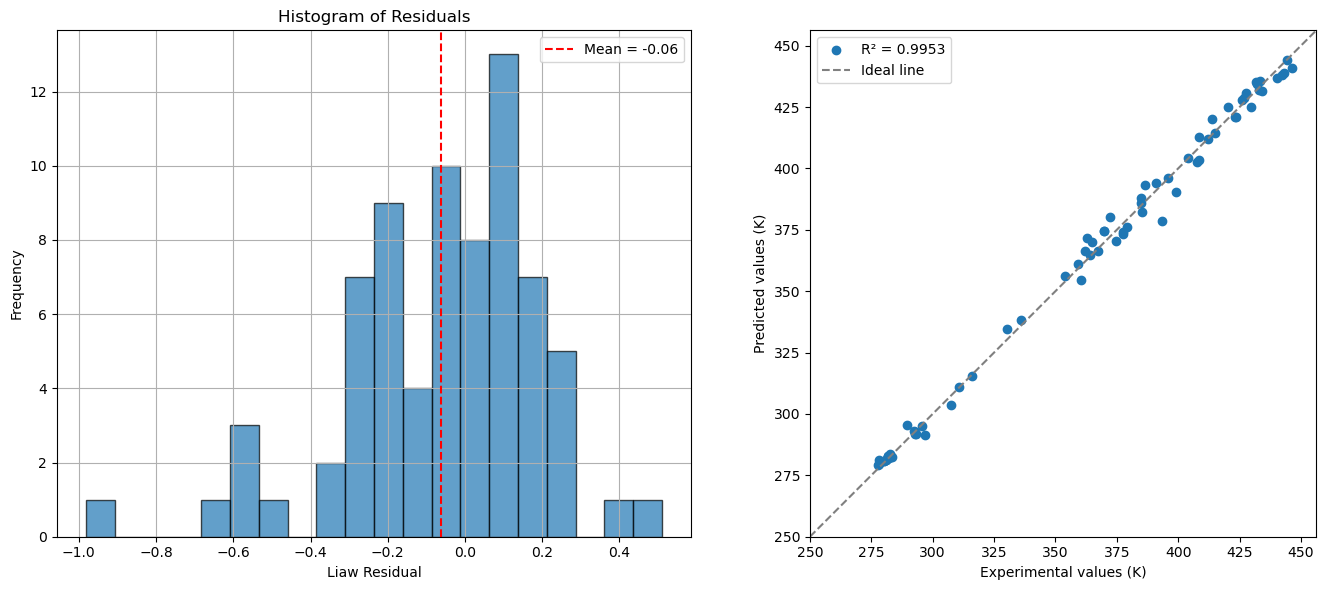

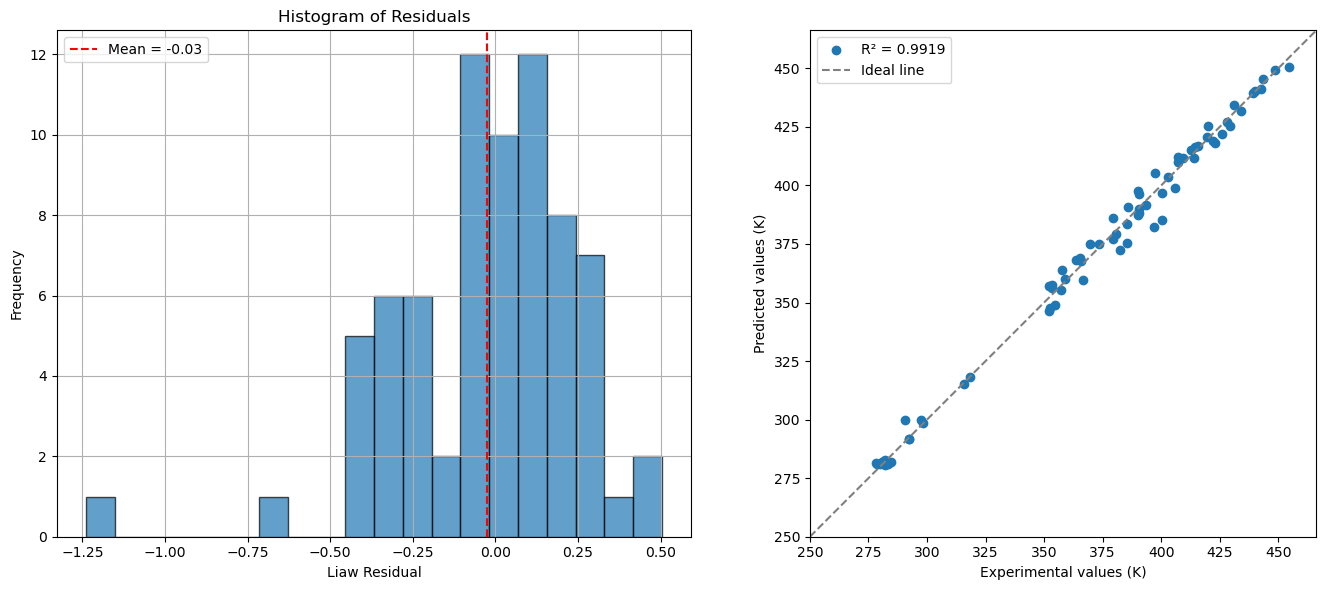

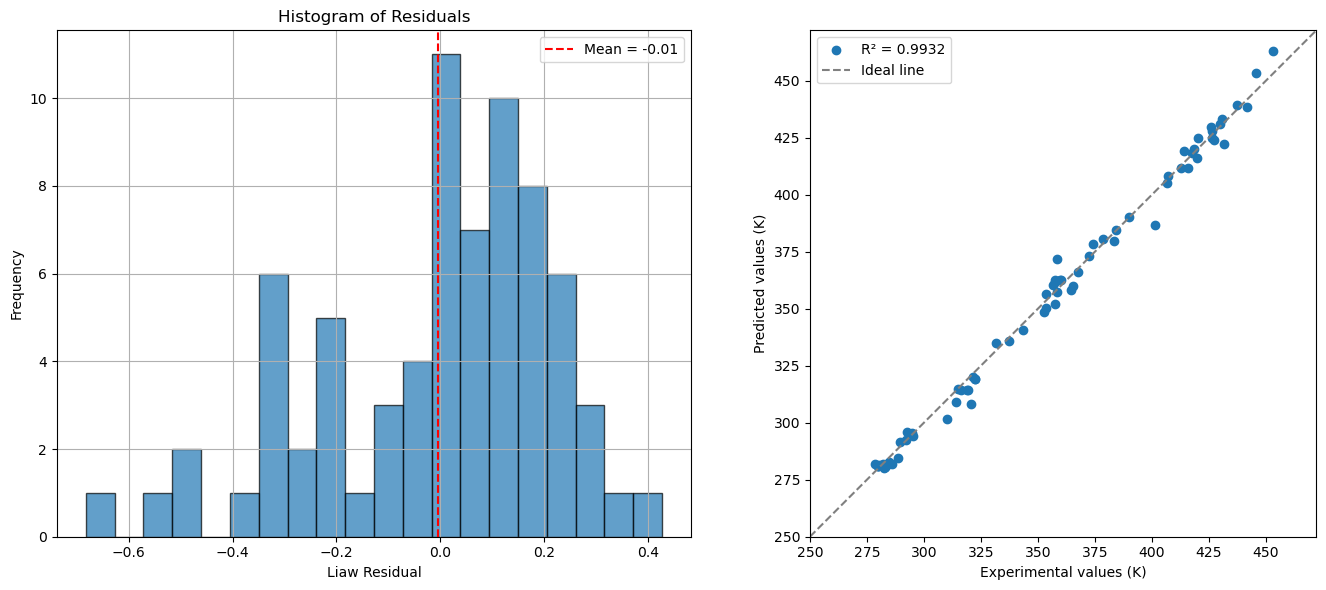

In [16]:
# Define the cross-validation folds
folds = 5
kf = KFold(n_splits=folds, shuffle=True, random_state=42)

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(features)):
    # Split data into train and validation
    X_train_fold, X_val_fold = features[train_idx], features[val_idx]
    y_train_fold, y_val_fold = label[train_idx], label[val_idx]

    # Scaler for FP model
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold[:, :-4])
    X_val_scaled = scaler.transform(X_val_fold[:, :-4])

    # Convert to tensors
    X_train_tensor = torch.tensor(
        X_train_scaled, dtype=torch.float32, requires_grad=True
    ).to(DEVICE)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).to(DEVICE)
    X_val_tensor = torch.tensor(
        X_val_scaled, dtype=torch.float32, requires_grad=True
    ).to(DEVICE)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).to(DEVICE)

    # Get molar fraction tensor
    mol_frac_train = X_train_fold[:, 3:5].astype(np.float32)
    mol_frac_val = X_val_fold[:, 3:5].astype(np.float32)
    mol_frac_train_tensor = torch.tensor(
        mol_frac_train, dtype=torch.float32, requires_grad=True
    ).to(DEVICE)
    mol_frac_val_tensor = torch.tensor(
        mol_frac_val, dtype=torch.float32, requires_grad=True
    ).to(DEVICE)

    # Model and optimizer for FP
    model = NeuralNetArchitecture(in_dim=X_train_tensor.shape[1], out_dim=1).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

    best_val_loss = float("inf")
    for epoch in range(EPOCHS):
        model.train()
        outputs = model(X_train_tensor)

        gamma = compute_activity_coefficients(
            X_train_fold[:, -2:], mol_frac_train, outputs
        )
        pvap, pvap_fp = compute_vapor_pressure(X_train_fold[:, -2:], outputs)

        loss, _ = custom_liaw_loss(
            outputs,
            y_train_tensor,
            mol_frac_train_tensor,
            gamma,
            pvap,
            pvap_fp,
            epoch,
            model,
            lambda_liaw=best_lambda_liaw,
            lambda_l1=best_lambda_l1,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        val_outputs = model(X_val_tensor)

        val_gamma = compute_activity_coefficients(
            X_val_fold[:, -2:], mol_frac_val, val_outputs
        )
        val_pvap, val_pvap_fp = compute_vapor_pressure(X_val_fold[:, -2:], val_outputs)

        val_loss, _ = custom_liaw_loss(
            val_outputs,
            y_val_tensor,
            mol_frac_val_tensor,
            val_gamma,
            val_pvap,
            val_pvap_fp,
            epoch,
            model,
            lambda_liaw=best_lambda_liaw,
            lambda_l1=best_lambda_l1,
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())

    # Plot predicted vs experimental
    model.load_state_dict(best_model_state)
    model.eval()

    # Save best model state and scaler for each fold
    torch.save(model.state_dict(), MODEL_PATH / f"unifac_best_model_fold_{fold_idx}.pt")
    joblib.dump(scaler, MODEL_PATH / f"unifac_scaler_model_fold_{fold_idx}.pkl")

    # Get test outputs for best model
    test_outputs = model(X_val_tensor)

    # Get the residuals
    _, test_residuals = custom_liaw_loss(
        test_outputs,
        y_val_tensor,
        mol_frac_val_tensor,
        val_gamma,
        val_pvap,
        val_pvap_fp,
        EPOCHS,
        model,
        best_lambda_liaw,
        best_lambda_l1,
    )

    np_liaw_residuals = test_residuals.detach().cpu().numpy()

    # Calculate R2
    r2_metric = R2Score()
    r2 = r2_metric(test_outputs[:, 0], y_val_tensor[:, 0]).item()

    # Convert to numpy array
    y_test_np = y_val_tensor[:, 0].cpu().numpy()
    preds_np = test_outputs[:, 0].detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plt.sca(axes[0])
    plot_residuals_histogram(np_liaw_residuals)
    plt.sca(axes[1])
    plot_pred_vs_exp(y_test_np, preds_np, r2)
    plt.tight_layout()
    plt.show()

### 1-Butanol + FAEEs Evaluation

Reading the data into a `pandas.DataFrame`:

In [17]:
but_faee_data = pd.read_csv(DATA_PATH / "processed" / "butanol_faee_data.csv")

but_faee_data

,substance_1,substance_2,x_1,x_2,MM,lnPvap,Method
0,Ethyl Octanoate,NaN,1.00,0.00,172.26460,3.074711,0
1,Butanol,Ethyl Octanoate,0.05,0.95,167.35750,4.171576,0
2,Butanol,Ethyl Octanoate,0.10,0.90,162.45030,4.682051,0
3,Butanol,Ethyl Octanoate,0.15,0.85,157.54320,5.018373,0
4,Butanol,Ethyl Octanoate,0.20,0.80,152.63600,5.269604,0
...,...,...,...,...,...,...,...
100,Butanol,Ethyl Myristate,0.80,0.20,110.58210,6.562587,0
101,Butanol,Ethyl Myristate,0.85,0.15,101.46700,6.623210,0
102,Butanol,Ethyl Myristate,0.90,0.10,92.35185,6.680367,0
103,Butanol,Ethyl Myristate,0.95,0.05,83.23673,6.734432,0


Load best model and scaler

In [18]:
model.load_state_dict(torch.load("../src/models/unifac_best_model_fold_4.pt"))
scaler = joblib.load("../src/models/unifac_scaler_model_fold_4.pkl")

Process the DataFrame into a tensor and make prediction

In [19]:
but_faee_array = but_faee_data.values

# Transform array
X_but_faee_scaled = scaler.transform(but_faee_array[:, -3:])

# Convert to tensor
X_but_faee_tensor = torch.tensor(
    X_but_faee_scaled, dtype=torch.float32, requires_grad=True
).to(DEVICE)

# Make prediction
but_faee_pred = model(X_but_faee_tensor)

for i in but_faee_pred:
    print(i[0].item())

355.97711181640625
344.0986022949219
337.15496826171875
332.13079833984375
328.2397766113281
325.30230712890625
323.23907470703125
321.62127685546875
320.61431884765625
319.7567138671875
319.01837158203125
318.377685546875
317.81829833984375
317.5250244140625
317.36700439453125
317.2540588378906
317.1536865234375
315.67498779296875
314.02398681640625
312.186767578125
310.3760986328125
383.2716064453125
351.7209167480469
342.30487060546875
336.3155517578125
331.8394775390625
328.2005920410156
325.09417724609375
322.3564453125
320.6224365234375
319.1146545410156
318.2955627441406
317.7086486816406
317.2098388671875
316.7850341796875
316.56610107421875
316.5818176269531
316.639404296875
316.39703369140625
314.71429443359375
312.57183837890625
310.3760986328125
405.3362731933594
355.4338073730469
345.3808288574219
339.1358947753906
334.4537048339844
330.6287536621094
327.3462829589844
324.4383850097656
321.80462646484375
319.47821044921875
318.0783996582031
316.8699035644531
316.4628295898